SOFTWARE LABORATORY III ASSIGNMENT 5

Data Analytics-II 1. Implement logistic 
regression using Python/R to perform 
classification on Social_Network_Ads.csv 
dataset. 
2. Compute Confusion matrix to find TP, 
FP, TN, FN, Accuracy, Error rate, 
Precision, Recall on the given dataset.

# 1. Import Libraries


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# 2. Load Dataset


In [9]:
dataset = pd.read_csv('Social_Network_Ads.csv')
print("First 5 rows:\n", dataset.head())
print("\nMissing Values:\n", dataset.isnull().sum())

First 5 rows:
     User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

Missing Values:
 User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


# 3. Preprocessing


In [10]:
# Features (Age, EstimatedSalary)
X = dataset.iloc[:, 2:-1].values

# Target (Purchased)
y = dataset.iloc[:, -1].values

# 4. Train-Test Split


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 5. Feature Scaling


In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Train Logistic Model


In [13]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# 7. Prediction


In [14]:
y_pred = model.predict(X_test)


# 8. Confusion Matrix


In [15]:
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
print("\nConfusion Matrix:\n", cm)
print(f"\nTP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")


Confusion Matrix:
 [[7 0]
 [0 5]]

TP: 5, TN: 7, FP: 0, FN: 0


# 9. Performance Metrics


In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
error_rate = 1 - accuracy
print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Error Rate:", error_rate)


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Error Rate: 0.0


# 10. Confusion Matrix Visualization


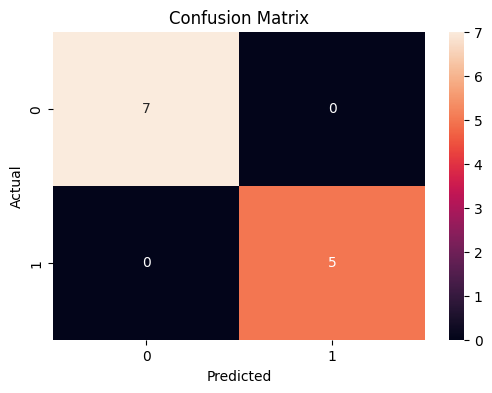

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()